# Initiate

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from openai import OpenAI
from ast import literal_eval
import json
import re
from sklearn.decomposition import PCA
import time
# ignore warnings
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_absolute_error
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import StrToComposition

In [ ]:
openrouter_api = "Your API Key"
client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=openrouter_api,
)

# Test (Skip if tested)

In [ ]:
# Define number of neighbors as few-shot examples
num_points = 25
Model = 'Your Model'

In [ ]:
with open('steels_yield.json') as json_data:
    data = json.load(json_data)
    df = pd.DataFrame(data['data'],columns=data['columns']).sample(frac=1, random_state=42).reset_index(drop=True)

# Custom function to parse the composition strings
def custom_parse_composition(comp_str):
    # Regular expression to match elements and their amounts
    pattern = re.compile(r'([A-Z][a-z]*)([0-9\.]+)')
    return dict(pattern.findall(comp_str))
# Apply the custom parsing function
element_data = df['composition'].apply(custom_parse_composition)
# Convert the list of dictionaries into a DataFrame
element_df = pd.DataFrame(list(element_data))
# Replace missing values with 0
element_df = element_df.fillna(0)
# Convert string numbers to float
element_df = element_df.apply(pd.to_numeric)
# Combine the element DataFrame with the original DataFrame
df = pd.concat([df, element_df], axis=1)
# PCA
n_components = min(element_df.shape)
pca = PCA(n_components)
pca.fit(element_df)
loading_vectors = pca.components_
explained_variance = pca.explained_variance_
pos = pca.transform(element_df)
PCA_list = pos
var = np.var(PCA_list,axis=0)
PVE = (var.T/var.sum()).T
pca.explained_variance_
pca.explained_variance_ratio_.max()
PC_values = np.arange(pca.n_components_) + 1
# Cumulative variance over the first 30 PCs. 
PC_values = np.arange(pca.n_components_) + 1
PC_cum_values = np.cumsum(PC_values)
# append pos to df
df['PC1'] = pos[:,0]
df['PC2'] = pos[:,1]

# for each point in df, find the nearest num_points points and append the indices of these points to a list called 'nearest neighbors'
nearest_neighbors = []
farthest_neighbors = []
random_indices = []
for i in range(len(df)):
    distances = []
    for j in range(len(df)):
            # find the distance between the two points using the first two PCs using sqrt( (x2 - x1)**2 + (y2 - y1)**2 )
            distances.append(np.sqrt((df['PC1'][j] - df['PC1'][i])**2 + (df['PC2'][j] - df['PC2'][i])**2))
    nearest_neighbors.append(np.argsort(distances)[:num_points+1])
    # drop the first index because it is the point itself
    nearest_neighbors[i] = np.delete(nearest_neighbors[i], 0)
    # append the farthest num_points points to a list called 'farthest neighbors'
    farthest_neighbors.append(np.argsort(distances)[-num_points:])
    # create a list of num_points indices of the random points excluding the point itself
    np.random.seed(42)
    random_indices.append(np.random.choice(np.delete(np.arange(len(df)), i), num_points))
df['nearest neighbors'] = nearest_neighbors
df['farthest neighbors'] = farthest_neighbors
df['random neighbors'] = random_indices

# define a function that forms three different train sets for each point in the dataframe
def create_train_sets(df):
    nearest_neighbors, farthest_neighbors, random_neighbors = [], [], []
    pattern = re.compile(r'([A-Z][a-z]*)([0-9\.e\-]*)')
    for i in range(len(df)):
        nearest_neighbors.append('')
        farthest_neighbors.append('')
        random_neighbors.append('')
        for j in range(len(df['nearest neighbors'][i])):
            comp = ''
            for match in pattern.finditer(df['composition'][df['nearest neighbors'][i][j]]):
                comp += match.group(1) + match.group(2) + ' '
            # Remove the last trailing space
            comp = comp.strip()
            nearest_neighbors[i] += 'composition: ' + comp + ', ' + 'yield strength: ' + '<' + str(df['yield strength'][df['nearest neighbors'][i][j]]) + '>\n'
        for j in range(len(df['farthest neighbors'][i])):
            comp = ''
            for match in pattern.finditer(df['composition'][df['farthest neighbors'][i][j]]):
                comp += match.group(1) + match.group(2) + ' '
            # Remove the last trailing space
            comp = comp.strip()
            farthest_neighbors[i] += 'composition: ' + comp + ', ' + 'yield strength: ' + '<' + str(df['yield strength'][df['farthest neighbors'][i][j]]) + '>\n'
        for j in range(len(df['random neighbors'][i])):
            comp = ''
            for match in pattern.finditer(df['composition'][df['random neighbors'][i][j]]):
                comp += match.group(1) + match.group(2) + ' '
            # Remove the last trailing space
            comp = comp.strip()
            random_neighbors[i] += 'composition: ' + comp + ', ' + 'yield strength: ' + '<' + str(df['yield strength'][df['random neighbors'][i][j]]) + '>\n'
    # append the three train sets to the dataframe
    df['nearest neighbors train'] = nearest_neighbors
    df['farthest neighbors train'] = farthest_neighbors
    df['random neighbors train'] = random_neighbors
    return df
df = create_train_sets(df)

def Predict_yield(train, composition, Model = "anthropic/claude-3.5-sonnet-20240620", Temperature = 0.0, sleep = 1):
    response = client.chat.completions.create(
      model= Model,
      messages=[{"role": "system", "content": 'Given some example alloy compositions and their yield strengths, predict the yield strength for one additional alloy composition.'},
                {"role": "user", "content": '###Examples### \n'+train+ '\nNow predict the yield strength for the following composition. \n\ncomposition: '+ composition+' \n\nWrite only the yield strength in a single numerical value that is enclosed by <>.'}
                ],
      temperature=Temperature,
    )
    time.sleep(sleep)
    #print(train)
    return response.choices[0].message.content

def test_run(df):
    # Initialize predicted columns if not already present
    if 'predicted nearest' not in df.columns:
        df['predicted nearest'] = [None] * len(df)
    if 'predicted farthest' not in df.columns:
        df['predicted farthest'] = [None] * len(df)
    if 'predicted random' not in df.columns:
        df['predicted random'] = [None] * len(df)

    pattern = re.compile(r'([A-Z][a-z]*)([0-9\.e\-]*)')

    for i in range(len(df)):
        # Skip rows where predictions are already complete
        if pd.notnull(df['predicted nearest'][i]) and pd.notnull(df['predicted farthest'][i]) and pd.notnull(df['predicted random'][i]):
            continue

        # Parse the composition string
        comp = ''.join([match.group(1) + match.group(2) + ' ' for match in pattern.finditer(df['composition'][i])]).strip()

        # Predict nearest neighbors if not already done
        if pd.isnull(df['predicted nearest'][i]):
            df.at[i, 'predicted nearest'] = Predict_yield(df['nearest neighbors train'][i], comp)

        # Predict farthest neighbors if not already done
        if pd.isnull(df['predicted farthest'][i]):
            df.at[i, 'predicted farthest'] = Predict_yield(df['farthest neighbors train'][i], comp)

        # Predict random neighbors if not already done
        if pd.isnull(df['predicted random'][i]):
            df.at[i, 'predicted random'] = Predict_yield(df['random neighbors train'][i], comp)

        # Save progress to avoid losing intermediate results
        df.to_csv('resumable_predictions.csv', index=False)

    return df
df = test_run(df, Model)

# save test into csv
df.to_csv('matbench_steels_Your_Model.csv', index=False)

# RFR (Skip if tested)

## RFR Trained on MAGPIE Features

In [76]:
with open('steels_yield.json') as json_data:
    data = json.load(json_data)
    df = pd.DataFrame(data['data'],columns=data['columns']).sample(frac=1, random_state=42).reset_index(drop=True)

# Custom function to parse the composition strings
def custom_parse_composition(comp_str):
    # Regular expression to match elements and their amounts
    pattern = re.compile(r'([A-Z][a-z]*)([0-9\.]+)')
    return dict(pattern.findall(comp_str))
# Apply the custom parsing function
element_data = df['composition'].apply(custom_parse_composition)
# Convert the list of dictionaries into a DataFrame
element_df = pd.DataFrame(list(element_data))
# Replace missing values with 0
element_df = element_df.fillna(0)
# Convert string numbers to float
element_df = element_df.apply(pd.to_numeric)
# Combine the element DataFrame with the original DataFrame
df = pd.concat([df, element_df], axis=1)
# PCA
n_components = min(element_df.shape)
pca = PCA(n_components)
pca.fit(element_df)
loading_vectors = pca.components_
explained_variance = pca.explained_variance_
pos = pca.transform(element_df)
PCA_list = pos
var = np.var(PCA_list,axis=0)
PVE = (var.T/var.sum()).T
pca.explained_variance_
pca.explained_variance_ratio_.max()
PC_values = np.arange(pca.n_components_) + 1
# Cumulative variance over the first 30 PCs. 
PC_values = np.arange(pca.n_components_) + 1
PC_cum_values = np.cumsum(PC_values)
# append pos to df
df['PC1'] = pos[:,0]
df['PC2'] = pos[:,1]

num_points = 25
# for each point in df, find the nearest num_points points and append the indices of these points to a list called 'nearest neighbors'
nearest_neighbors = []
farthest_neighbors = []
random_indices = []
for i in range(len(df)):
    distances = []
    for j in range(len(df)):
            # find the distance between the two points using the first two PCs using sqrt( (x2 - x1)**2 + (y2 - y1)**2 )
            distances.append(np.sqrt((df['PC1'][j] - df['PC1'][i])**2 + (df['PC2'][j] - df['PC2'][i])**2))
    nearest_neighbors.append(np.argsort(distances)[:num_points+1])
    # drop the first index because it is the point itself
    nearest_neighbors[i] = np.delete(nearest_neighbors[i], 0)
    # append the farthest num_points points to a list called 'farthest neighbors'
    farthest_neighbors.append(np.argsort(distances)[-num_points:])
    # create a list of num_points indices of the random points excluding the point itself
    np.random.seed(42)
    random_indices.append(np.random.choice(np.delete(np.arange(len(df)), i), num_points))
df['nearest neighbors'] = nearest_neighbors
df['farthest neighbors'] = farthest_neighbors
df['random neighbors'] = random_indices


# rename composition to composition_original
df = df.rename(columns={'composition': 'composition_original'})

# Convert Formula string to composition
featurized_data = StrToComposition().featurize_dataframe(df, "composition_original")

# Featurized the data based on the composition using ElementProperty (structural properties)
features = ["Number", "MendeleevNumber", "AtomicWeight", "MeltingT", "Column", "Row", 
"CovalentRadius", "Electronegativity", "NsValence", "NpValence", "NdValence", "NfValence", "NValence", 
"NsUnfilled", "NpUnfilled", "NdUnfilled", "NfUnfilled", "NUnfilled","GSvolume_pa", "GSbandgap", 
"GSmagmom"]
stats = ["mean", "avg_dev", "minimum", "maximum", "range"]
featurized_data = ElementProperty('magpie', features, stats).featurize_dataframe(featurized_data, "composition")

df = featurized_data


# define a function that forms three different train sets for each point in the dataframe
def create_train_sets(df):
    y_pred_nearest_neighbors, y_pred_farthest_neighbors, y_pred_random_neighbors = [], [], []
    y_test = np.array(df['yield strength'])
    for i in range(len(df)):
        #print(i)
        X_test = np.array(df.iloc[i,22:]).reshape(1,-1)
        x_train_nearest, y_train_nearest, x_train_farthest, y_train_farthest, x_train_random, y_train_random = [], [], [], [], [], []
        for j in range(len(df['nearest neighbors'][i])):
            y_train_nearest.append(df['yield strength'][df['nearest neighbors'][i][j]])
            x_train_nearest.append(list(df.iloc[df['nearest neighbors'][i][j],22:]))
            # train the model
            rfr_nearest = RandomForestRegressor(random_state=42)
            rfr_nearest.fit(x_train_nearest, y_train_nearest)
        for j in range(len(df['farthest neighbors'][i])):
            y_train_farthest.append(df['yield strength'][df['farthest neighbors'][i][j]])
            x_train_farthest.append(list(df.iloc[df['farthest neighbors'][i][j],22:]))
            # train the model
            rfr_farthest = RandomForestRegressor(random_state=42)
            rfr_farthest.fit(x_train_farthest, y_train_farthest)
        for j in range(len(df['random neighbors'][i])):
            y_train_random.append(df['yield strength'][df['random neighbors'][i][j]])
            x_train_random.append(list(df.iloc[df['random neighbors'][i][j],22:]))
            # train the model
            rfr_random = RandomForestRegressor(random_state=42)
            rfr_random.fit(x_train_random, y_train_random)
        y_pred_nearest_neighbors.append(rfr_nearest.predict(X_test))
        y_pred_farthest_neighbors.append(rfr_farthest.predict(X_test))
        y_pred_random_neighbors.append(rfr_random.predict(X_test))
    #return y_pred_nearest_neighbors, y_pred_farthest_neighbors, y_pred_random_neighbors
    # calculate the MAE for each of the three train sets
    MAE_nearest = mean_absolute_error(y_test, y_pred_nearest_neighbors)
    MAE_farthest = mean_absolute_error(y_test, y_pred_farthest_neighbors)
    MAE_random = mean_absolute_error(y_test, y_pred_random_neighbors)
    return MAE_nearest, MAE_farthest, MAE_random

ElementProperty: 100%|██████████| 312/312 [00:03<00:00, 89.18it/s] 


In [69]:
# 5 points
MAE_nearest, MAE_farthest, MAE_random = create_train_sets(df)
print(MAE_farthest, MAE_random, MAE_nearest)

425.12684615384654 282.5469871794877 109.13726602564101


In [71]:
# 10 points
MAE_nearest, MAE_farthest, MAE_random = create_train_sets(df)
print(MAE_farthest, MAE_random, MAE_nearest)

348.47262499999994 240.31389423076942 100.62711217948711


In [73]:
# 15 points
MAE_nearest, MAE_farthest, MAE_random = create_train_sets(df)
print(MAE_farthest, MAE_random, MAE_nearest)

376.93650320512836 207.3678846153847 101.75645512820512


In [75]:
# 20 points
MAE_nearest, MAE_farthest, MAE_random = create_train_sets(df)
print(MAE_farthest, MAE_random, MAE_nearest)

361.6474711538464 201.374766025641 100.27597435897435


In [77]:
# 25 points
MAE_nearest, MAE_farthest, MAE_random = create_train_sets(df)
print(MAE_farthest, MAE_random, MAE_nearest)

339.5339070512824 192.8348044871795 97.58925961538459


## RFR Trained on Compositions

In [11]:
with open('steels_yield.json') as json_data:
    data = json.load(json_data)
    df = pd.DataFrame(data['data'],columns=data['columns']).sample(frac=1, random_state=42).reset_index(drop=True)

# Custom function to parse the composition strings
def custom_parse_composition(comp_str):
    # Regular expression to match elements and their amounts
    pattern = re.compile(r'([A-Z][a-z]*)([0-9\.e\-]*)')
    return dict(pattern.findall(comp_str))
# Apply the custom parsing function
element_data = df['composition'].apply(custom_parse_composition)
# Convert the list of dictionaries into a DataFrame
element_df = pd.DataFrame(list(element_data))
# Replace missing values with 0
element_df = element_df.fillna(0)
# Convert string numbers to float
element_df = element_df.apply(pd.to_numeric)
# Combine the element DataFrame with the original DataFrame
df = pd.concat([df, element_df], axis=1)
# PCA
n_components = min(element_df.shape)
pca = PCA(n_components)
pca.fit(element_df)
loading_vectors = pca.components_
explained_variance = pca.explained_variance_
pos = pca.transform(element_df)
PCA_list = pos
var = np.var(PCA_list,axis=0)
PVE = (var.T/var.sum()).T
pca.explained_variance_
pca.explained_variance_ratio_.max()
PC_values = np.arange(pca.n_components_) + 1
# Cumulative variance over the first 30 PCs. 
PC_values = np.arange(pca.n_components_) + 1
PC_cum_values = np.cumsum(PC_values)
# append pos to df
df['PC1'] = pos[:,0]
df['PC2'] = pos[:,1]

num_points = 5
# for each point in df, find the nearest num_points points and append the indices of these points to a list called 'nearest neighbors'
nearest_neighbors = []
farthest_neighbors = []
random_indices = []
for i in range(len(df)):
    distances = []
    for j in range(len(df)):
            # find the distance between the two points using the first two PCs using sqrt( (x2 - x1)**2 + (y2 - y1)**2 )
            distances.append(np.sqrt((df['PC1'][j] - df['PC1'][i])**2 + (df['PC2'][j] - df['PC2'][i])**2))
    nearest_neighbors.append(np.argsort(distances)[:num_points+1])
    # drop the first index because it is the point itself
    nearest_neighbors[i] = np.delete(nearest_neighbors[i], 0)
    # append the farthest num_points points to a list called 'farthest neighbors'
    farthest_neighbors.append(np.argsort(distances)[-num_points:])
    # create a list of num_points indices of the random points excluding the point itself
    np.random.seed(42)
    random_indices.append(np.random.choice(np.delete(np.arange(len(df)), i), num_points))
df['nearest neighbors'] = nearest_neighbors
df['farthest neighbors'] = farthest_neighbors
df['random neighbors'] = random_indices

# define a function that forms three different train sets for each point in the dataframe
def create_train_sets(df):
    y_pred_nearest_neighbors, y_pred_farthest_neighbors, y_pred_random_neighbors = [], [], []
    y_test = np.array(df['yield strength'])
    for i in range(len(df)):
        #print(i)
        X_test = np.array(df.iloc[i,2:-5]).reshape(1,-1)
        x_train_nearest, y_train_nearest, x_train_farthest, y_train_farthest, x_train_random, y_train_random = [], [], [], [], [], []
        for j in range(len(df['nearest neighbors'][i])):
            y_train_nearest.append(df['yield strength'][df['nearest neighbors'][i][j]])
            x_train_nearest.append(list(df.iloc[df['nearest neighbors'][i][j],2:-5]))
            # train the model
            rfr_nearest = RandomForestRegressor(random_state=42)
            rfr_nearest.fit(x_train_nearest, y_train_nearest)
        for j in range(len(df['farthest neighbors'][i])):
            y_train_farthest.append(df['yield strength'][df['farthest neighbors'][i][j]])
            x_train_farthest.append(list(df.iloc[df['farthest neighbors'][i][j],2:-5]))
            # train the model
            rfr_farthest = RandomForestRegressor(random_state=42)
            rfr_farthest.fit(x_train_farthest, y_train_farthest)
        for j in range(len(df['random neighbors'][i])):
            y_train_random.append(df['yield strength'][df['random neighbors'][i][j]])
            x_train_random.append(list(df.iloc[df['random neighbors'][i][j],2:-5]))
            # train the model
            rfr_random = RandomForestRegressor(random_state=42)
            rfr_random.fit(x_train_random, y_train_random)
        y_pred_nearest_neighbors.append(rfr_nearest.predict(X_test))
        y_pred_farthest_neighbors.append(rfr_farthest.predict(X_test))
        y_pred_random_neighbors.append(rfr_random.predict(X_test))
    #return y_pred_nearest_neighbors, y_pred_farthest_neighbors, y_pred_random_neighbors
    # calculate the MAE for each of the three train sets
    MAE_nearest = mean_absolute_error(y_test, y_pred_nearest_neighbors)
    MAE_farthest = mean_absolute_error(y_test, y_pred_farthest_neighbors)
    MAE_random = mean_absolute_error(y_test, y_pred_random_neighbors)
    return MAE_nearest, MAE_farthest, MAE_random

In [4]:
# 25 points
MAE_nearest, MAE_farthest, MAE_random = create_train_sets(df)
print(MAE_farthest, MAE_random, MAE_nearest)

377.39881730769224 193.2795480769231 85.35734615384617


In [6]:
# 20 points
MAE_nearest, MAE_farthest, MAE_random = create_train_sets(df)
print(MAE_farthest, MAE_random, MAE_nearest)

383.6299935897437 198.91015384615397 87.96908653846153


In [8]:
# 15 points
MAE_nearest, MAE_farthest, MAE_random = create_train_sets(df)
print(MAE_farthest, MAE_random, MAE_nearest)

381.7618076923079 200.2966987179488 90.25058012820521


In [10]:
# 10 points
MAE_nearest, MAE_farthest, MAE_random = create_train_sets(df)
print(MAE_farthest, MAE_random, MAE_nearest)

374.3786506410256 249.1235833333335 95.0475929487179


In [12]:
# 5 points
MAE_nearest, MAE_farthest, MAE_random = create_train_sets(df)
print(MAE_farthest, MAE_random, MAE_nearest)

437.66208974359006 306.81387820512873 109.33418589743586


# Plot all

In [13]:
# Extract the numeric value that is enclosed by the "<" and ">" symbols
def extract_numeric_value(string):
    return float(re.search('<(.+?)>', string).group(1))

# Use namestr to dynamically extract the variable name
def namestr(obj, namespace):
    return [name for name in namespace if namespace[name] is obj][0]

# For columns with 'predicted' in the name
def extract_predicted_yield_strength(df, namespace = globals()):
    # Dynamically get the dataset variable name
    dataset_name = namestr(df, namespace)
    
    predicted_cols = [col for col in df.columns if 'predicted' in col]
    total_rows = df.shape[0]  # Total number of rows before processing
    success_count = 0
    fail_count = 0

    for col in predicted_cols:
        if '_yield_strength' in col:
            break
        # Create a new column with the same name plus '_yield_strength'
        df[col+'_yield_strength'] = np.nan
        for i in range(df.shape[0]):
            s = df[col][i]
            if pd.isnull(s):
                fail_count += 1
                continue
            # Keep everything before the last 'MPa'
            s = s.rsplit('MPa', 1)[0]
            p = r'[\d]*[.][\d]+'  # Match float numbers
            try:
                df.at[i, col+'_yield_strength'] = extract_numeric_value(s)
                success_count += 1
            except:
                try:
                    df.at[i, col+'_yield_strength'] = float(re.findall(p, s)[-1])
                    success_count += 1
                except:
                    fail_count += 1

    # Drop rows with NaN in any of the new '_yield_strength' columns
    rows_before_drop = df.shape[0]
    df = df.dropna()
    rows_after_drop = df.shape[0]

    # Drop rows if any '_yield_strength' columns have values less than 1
    for col in predicted_cols:
        df = df[df[col+'_yield_strength'] > 1]

    final_rows = df.shape[0]
    print(f"Dataset: {dataset_name}")
    print(f"Total rows: {total_rows}")
    print(f"Rows successfully processed: {success_count}")
    print(f"Rows with extraction failures: {fail_count}")
    print(f"Rows dropped due to NaN: {rows_before_drop - rows_after_drop}")
    print(f"Rows dropped due to low yield strength: {rows_after_drop - final_rows}")
    print(f"Final remaining rows: {final_rows}")

    return df


In [14]:
# 5 points
claude_35_sonnet_retrieval_5points = pd.read_csv('matbench_steels_claude-3.5-sonnet-20240620_5points.csv')
gpt_35_turbo_retrieval_5points = pd.read_csv('matbench_steels_gpt-3.5-turbo-1106_5points.csv') 
cohere_command_r7b_retrieval_5points = pd.read_csv('matbench_steels_command-r7b-12-2024_5points.csv')
cohere_command_a_retrieval_5points = pd.read_csv('matbench_steels_command-a_5points.csv')
mistral_large_retrieval_5points = pd.read_csv('matbench_steels_mistral-large-2411_5points.csv')
llama_33_70b_retrieval_5points = pd.read_csv('matbench_steels_llama-3.3-70b-instruct_5points.csv')
gpt_4o_retrieval_5points = pd.read_csv('matbench_steels_GPT-4o (2024-11-20)_5points.csv')
# 10 points
claude_35_sonnet_retrieval_10points = pd.read_csv('matbench_steels_claude-3.5-sonnet-20240620_10points.csv')
gpt_35_turbo_retrieval_10points = pd.read_csv('matbench_steels_gpt-3.5-turbo-1106_10points.csv') 
cohere_command_r7b_retrieval_10points = pd.read_csv('matbench_steels_command-r7b-12-2024_10points.csv')
cohere_command_a_retrieval_10points = pd.read_csv('matbench_steels_command-a_10points.csv')
mistral_large_retrieval_10points = pd.read_csv('matbench_steels_mistral-large-2411_10points.csv')
llama_33_70b_retrieval_10points = pd.read_csv('matbench_steels_llama-3.3-70b-instruct_10points.csv')
gpt_4o_retrieval_10points = pd.read_csv('matbench_steels_GPT-4o (2024-11-20)_10points.csv')
# 15 points
claude_35_sonnet_retrieval_15points = pd.read_csv('matbench_steels_claude-3.5-sonnet-20240620_15points.csv')
gpt_35_turbo_retrieval_15points = pd.read_csv('matbench_steels_gpt-3.5-turbo-1106_15points.csv') 
cohere_command_r7b_retrieval_15points = pd.read_csv('matbench_steels_command-r7b-12-2024_15points.csv')
cohere_command_a_retrieval_15points = pd.read_csv('matbench_steels_command-a_15points.csv')
mistral_large_retrieval_15points = pd.read_csv('matbench_steels_mistral-large-2411_15points.csv')
llama_33_70b_retrieval_15points = pd.read_csv('matbench_steels_llama-3.3-70b-instruct_15points.csv')
gpt_4o_retrieval_15points = pd.read_csv('matbench_steels_GPT-4o (2024-11-20)_15points.csv')
# 20 points
claude_35_sonnet_retrieval_20points = pd.read_csv('matbench_steels_claude-3.5-sonnet-20240620_20points.csv')
gpt_35_turbo_retrieval_20points = pd.read_csv('matbench_steels_gpt-3.5-turbo-1106_20points.csv') 
cohere_command_r7b_retrieval_20points = pd.read_csv('matbench_steels_command-r7b-12-2024_20points.csv')
cohere_command_a_retrieval_20points = pd.read_csv('matbench_steels_command-a_20points.csv')
mistral_large_retrieval_20points = pd.read_csv('matbench_steels_mistral-large-2411_20points.csv')
llama_33_70b_retrieval_20points = pd.read_csv('matbench_steels_llama-3.3-70b-instruct_20points.csv')
gpt_4o_retrieval_20points = pd.read_csv('matbench_steels_GPT-4o (2024-11-20)_20points.csv')
# 25 points
#gpt_35_turbo_retrieval_25points = pd.read_csv('gpt-3.5-turbo-0613_enclosure_neighbour_retrieval_eprompt_noexample_25points.csv')
claude_35_sonnet_retrieval_25points = pd.read_csv('matbench_steels_claude-3.5-sonnet-20240620_25points.csv')
gpt_35_turbo_retrieval_25points = pd.read_csv('matbench_steels_gpt-3.5-turbo-1106_25points.csv') #fixed
cohere_command_r7b_retrieval_25points = pd.read_csv('matbench_steels_command-r7b-12-2024_25points.csv')
cohere_command_a_retrieval_25points = pd.read_csv('matbench_steels_command-a_25points.csv')
mistral_large_retrieval_25points = pd.read_csv('matbench_steels_mistral-large-2411_25points.csv')
llama_33_70b_retrieval_25points = pd.read_csv('matbench_steels_llama-3.3-70b-instruct_25points.csv')
gpt_4o_retrieval_25points = pd.read_csv('matbench_steels_GPT-4o (2024-11-20)_25points.csv')

# Extract the predicted yield strength from the 'predicted' columns
claude_35_sonnet_retrieval_5points = extract_predicted_yield_strength(claude_35_sonnet_retrieval_5points)
claude_35_sonnet_retrieval_10points = extract_predicted_yield_strength(claude_35_sonnet_retrieval_10points)
claude_35_sonnet_retrieval_15points = extract_predicted_yield_strength(claude_35_sonnet_retrieval_15points)
claude_35_sonnet_retrieval_20points = extract_predicted_yield_strength(claude_35_sonnet_retrieval_20points)
claude_35_sonnet_retrieval_25points = extract_predicted_yield_strength(claude_35_sonnet_retrieval_25points)

gpt_35_turbo_retrieval_5points = extract_predicted_yield_strength(gpt_35_turbo_retrieval_5points)
gpt_35_turbo_retrieval_10points = extract_predicted_yield_strength(gpt_35_turbo_retrieval_10points)
gpt_35_turbo_retrieval_15points = extract_predicted_yield_strength(gpt_35_turbo_retrieval_15points)
gpt_35_turbo_retrieval_20points = extract_predicted_yield_strength(gpt_35_turbo_retrieval_20points)
gpt_35_turbo_retrieval_25points = extract_predicted_yield_strength(gpt_35_turbo_retrieval_25points)

cohere_command_r7b_retrieval_5points = extract_predicted_yield_strength(cohere_command_r7b_retrieval_5points)
cohere_command_r7b_retrieval_10points = extract_predicted_yield_strength(cohere_command_r7b_retrieval_10points)
cohere_command_r7b_retrieval_15points = extract_predicted_yield_strength(cohere_command_r7b_retrieval_15points)
cohere_command_r7b_retrieval_20points = extract_predicted_yield_strength(cohere_command_r7b_retrieval_20points)
cohere_command_r7b_retrieval_25points = extract_predicted_yield_strength(cohere_command_r7b_retrieval_25points)

cohere_command_a_retrieval_5points = extract_predicted_yield_strength(cohere_command_a_retrieval_5points)
cohere_command_a_retrieval_10points = extract_predicted_yield_strength(cohere_command_a_retrieval_10points)
cohere_command_a_retrieval_15points = extract_predicted_yield_strength(cohere_command_a_retrieval_15points)
cohere_command_a_retrieval_20points = extract_predicted_yield_strength(cohere_command_a_retrieval_20points)
cohere_command_a_retrieval_25points = extract_predicted_yield_strength(cohere_command_a_retrieval_25points)

mistral_large_retrieval_5points = extract_predicted_yield_strength(mistral_large_retrieval_5points)
mistral_large_retrieval_10points = extract_predicted_yield_strength(mistral_large_retrieval_10points)
mistral_large_retrieval_15points = extract_predicted_yield_strength(mistral_large_retrieval_15points)
mistral_large_retrieval_20points = extract_predicted_yield_strength(mistral_large_retrieval_20points)
mistral_large_retrieval_25points = extract_predicted_yield_strength(mistral_large_retrieval_25points)

llama_33_70b_retrieval_5points = extract_predicted_yield_strength(llama_33_70b_retrieval_5points)
llama_33_70b_retrieval_10points = extract_predicted_yield_strength(llama_33_70b_retrieval_10points)
llama_33_70b_retrieval_15points = extract_predicted_yield_strength(llama_33_70b_retrieval_15points)
llama_33_70b_retrieval_20points = extract_predicted_yield_strength(llama_33_70b_retrieval_20points)
llama_33_70b_retrieval_25points = extract_predicted_yield_strength(llama_33_70b_retrieval_25points)

gpt_4o_retrieval_5points = extract_predicted_yield_strength(gpt_4o_retrieval_5points)
gpt_4o_retrieval_10points = extract_predicted_yield_strength(gpt_4o_retrieval_10points)
gpt_4o_retrieval_15points = extract_predicted_yield_strength(gpt_4o_retrieval_15points)
gpt_4o_retrieval_20points = extract_predicted_yield_strength(gpt_4o_retrieval_20points)
gpt_4o_retrieval_25points = extract_predicted_yield_strength(gpt_4o_retrieval_25points)

Dataset: claude_35_sonnet_retrieval_5points
Total rows: 312
Rows successfully processed: 936
Rows with extraction failures: 0
Rows dropped due to NaN: 0
Rows dropped due to low yield strength: 0
Final remaining rows: 312
Dataset: claude_35_sonnet_retrieval_10points
Total rows: 312
Rows successfully processed: 936
Rows with extraction failures: 0
Rows dropped due to NaN: 0
Rows dropped due to low yield strength: 0
Final remaining rows: 312
Dataset: claude_35_sonnet_retrieval_15points
Total rows: 312
Rows successfully processed: 936
Rows with extraction failures: 0
Rows dropped due to NaN: 0
Rows dropped due to low yield strength: 0
Final remaining rows: 312
Dataset: claude_35_sonnet_retrieval_20points
Total rows: 312
Rows successfully processed: 936
Rows with extraction failures: 0
Rows dropped due to NaN: 0
Rows dropped due to low yield strength: 0
Final remaining rows: 312
Dataset: claude_35_sonnet_retrieval_25points
Total rows: 312
Rows successfully processed: 936
Rows with extractio

In [15]:
def plot_parity_retrieval(df, model_name, plot=False):
    predicted_cols = ['predicted farthest', 'predicted random', 'predicted nearest']
    # do the same plot for every predicted yield strength
    for col in predicted_cols:
        # show r^2
        r2 = np.corrcoef(df['yield strength'],df[col+'_yield_strength'])[0,1]**2
        # calculate MAE
        MAE = np.mean(np.abs(df['yield strength']-df[col+'_yield_strength']))
        if plot:
            plt.figure(figsize=(8,8))
            plt.scatter(df['yield strength'],df[col+'_yield_strength'])
            # draw a diagonal line
            x = np.linspace(1000, 2500, 1000)
            y = x
            plt.plot(x, y, '-r', label='y=x')
            print('R^2: ', round(r2, 2))
            print('MAE: ', round(MAE,2))
            plt.xlabel('Actual Yield Strength (MPa)')
            plt.ylabel('Predicted Yield Strength (MPa)')
            # title with the name of the column
            plt.title('Parity plot of predicted yield strength vs. actual yield strength\n' + model_name + ' ' + col)
            #plot the R^2 and MAE on the plot
            plt.text(2000, 2500, 'R^2 = ' + str(round(r2, 2)))
            plt.text(2000, 2400, 'MAE = ' + str(round(MAE, 2)))
            plt.show()
        # create a df that stores the R^2 and MAE for each column
        if col == predicted_cols[0]:
            df_r2_mae = pd.DataFrame([[col, r2, MAE]], columns=['column', 'R^2', 'MAE'])
        else:
            df_r2_mae = df_r2_mae.append({'column': col, 'R^2': r2, 'MAE': MAE}, ignore_index=True)

    return df_r2_mae

In [16]:
claude_35_sonnet_retrieval_5points_stats = plot_parity_retrieval(claude_35_sonnet_retrieval_5points, 'claude_35_sonnet_retrieval_5points')
claude_35_sonnet_retrieval_10points_stats = plot_parity_retrieval(claude_35_sonnet_retrieval_10points, 'claude_35_sonnet_retrieval_10points')
claude_35_sonnet_retrieval_15points_stats = plot_parity_retrieval(claude_35_sonnet_retrieval_15points, 'claude_35_sonnet_retrieval_15points')
claude_35_sonnet_retrieval_20points_stats = plot_parity_retrieval(claude_35_sonnet_retrieval_20points, 'claude_35_sonnet_retrieval_20points')
claude_35_sonnet_retrieval_25points_stats = plot_parity_retrieval(claude_35_sonnet_retrieval_25points, 'claude_35_sonnet_retrieval_25points')

gpt_35_turbo_retrieval_5points_stats = plot_parity_retrieval(gpt_35_turbo_retrieval_5points, 'gpt_35_turbo_retrieval_5points')
gpt_35_turbo_retrieval_10points_stats = plot_parity_retrieval(gpt_35_turbo_retrieval_10points, 'gpt_35_turbo_retrieval_10points')
gpt_35_turbo_retrieval_15points_stats = plot_parity_retrieval(gpt_35_turbo_retrieval_15points, 'gpt_35_turbo_retrieval_15points')
gpt_35_turbo_retrieval_20points_stats = plot_parity_retrieval(gpt_35_turbo_retrieval_20points, 'gpt_35_turbo_retrieval_20points')
gpt_35_turbo_retrieval_25points_stats = plot_parity_retrieval(gpt_35_turbo_retrieval_25points, 'gpt_35_turbo_retrieval_25points')

cohere_command_r7b_retrieval_5points_stats = plot_parity_retrieval(cohere_command_r7b_retrieval_5points, 'cohere_command_r7b_retrieval_5points')
cohere_command_r7b_retrieval_10points_stats = plot_parity_retrieval(cohere_command_r7b_retrieval_10points, 'cohere_command_r7b_retrieval_10points')
cohere_command_r7b_retrieval_15points_stats = plot_parity_retrieval(cohere_command_r7b_retrieval_15points, 'cohere_command_r7b_retrieval_15points')
cohere_command_r7b_retrieval_20points_stats = plot_parity_retrieval(cohere_command_r7b_retrieval_20points, 'cohere_command_r7b_retrieval_20points')
cohere_command_r7b_retrieval_25points_stats = plot_parity_retrieval(cohere_command_r7b_retrieval_25points, 'cohere_command_r7b_retrieval_25points')

cohere_command_a_retrieval_5points_stats = plot_parity_retrieval(cohere_command_a_retrieval_5points, 'cohere_command_a_retrieval_5points')
cohere_command_a_retrieval_10points_stats = plot_parity_retrieval(cohere_command_a_retrieval_10points, 'cohere_command_a_retrieval_10points')
cohere_command_a_retrieval_15points_stats = plot_parity_retrieval(cohere_command_a_retrieval_15points, 'cohere_command_a_retrieval_15points')
cohere_command_a_retrieval_20points_stats = plot_parity_retrieval(cohere_command_a_retrieval_20points, 'cohere_command_a_retrieval_20points')
cohere_command_a_retrieval_25points_stats = plot_parity_retrieval(cohere_command_a_retrieval_25points, 'cohere_command_a_retrieval_25points')

mistral_large_retrieval_5points_stats = plot_parity_retrieval(mistral_large_retrieval_5points, 'mistral_large_retrieval_5points')
mistral_large_retrieval_10points_stats = plot_parity_retrieval(mistral_large_retrieval_10points, 'mistral_large_retrieval_10points')
mistral_large_retrieval_15points_stats = plot_parity_retrieval(mistral_large_retrieval_15points, 'mistral_large_retrieval_15points')
mistral_large_retrieval_20points_stats = plot_parity_retrieval(mistral_large_retrieval_20points, 'mistral_large_retrieval_20points')
mistral_large_retrieval_25points_stats = plot_parity_retrieval(mistral_large_retrieval_25points, 'mistral_large_retrieval_25points')

llama_33_70b_retrieval_5points_stats = plot_parity_retrieval(llama_33_70b_retrieval_5points, 'llama_33_70b_retrieval_5points')
llama_33_70b_retrieval_10points_stats = plot_parity_retrieval(llama_33_70b_retrieval_10points, 'llama_33_70b_retrieval_10points')
llama_33_70b_retrieval_15points_stats = plot_parity_retrieval(llama_33_70b_retrieval_15points, 'llama_33_70b_retrieval_15points')
llama_33_70b_retrieval_20points_stats = plot_parity_retrieval(llama_33_70b_retrieval_20points, 'llama_33_70b_retrieval_20points')
llama_33_70b_retrieval_25points_stats = plot_parity_retrieval(llama_33_70b_retrieval_25points, 'llama_33_70b_retrieval_25points')

gpt_4o_retrieval_5points_stats = plot_parity_retrieval(gpt_4o_retrieval_5points, 'gpt_4o_retrieval_5points')
gpt_4o_retrieval_10points_stats = plot_parity_retrieval(gpt_4o_retrieval_10points, 'gpt_4o_retrieval_10points')
gpt_4o_retrieval_15points_stats = plot_parity_retrieval(gpt_4o_retrieval_15points, 'gpt_4o_retrieval_15points')
gpt_4o_retrieval_20points_stats = plot_parity_retrieval(gpt_4o_retrieval_20points, 'gpt_4o_retrieval_20points')
gpt_4o_retrieval_25points_stats = plot_parity_retrieval(gpt_4o_retrieval_25points, 'gpt_4o_retrieval_25points')


In [17]:
# Baseline Model
with open('steels_yield.json') as json_data:
    data = json.load(json_data)
    df = pd.DataFrame(data['data'],columns=data['columns']).sample(frac=1, random_state=42).reset_index(drop=True)

def baseline_MAE(df,num_points):
    # Custom function to parse the composition strings
    def custom_parse_composition(comp_str):
        # Regular expression to match elements and their amounts
        pattern = re.compile(r'([A-Z][a-z]*)([0-9\.]+)')
        return dict(pattern.findall(comp_str))
    # Apply the custom parsing function
    element_data = df['composition'].apply(custom_parse_composition)
    # Convert the list of dictionaries into a DataFrame
    element_df = pd.DataFrame(list(element_data))
    # Replace missing values with 0
    element_df = element_df.fillna(0)
    # Convert string numbers to float
    element_df = element_df.apply(pd.to_numeric)
    # Combine the element DataFrame with the original DataFrame
    df = pd.concat([df, element_df], axis=1)
    # PCA
    n_components = min(element_df.shape)
    pca = PCA(n_components)
    pca.fit(element_df)
    loading_vectors = pca.components_
    explained_variance = pca.explained_variance_
    pos = pca.transform(element_df)
    PCA_list = pos
    var = np.var(PCA_list,axis=0)
    PVE = (var.T/var.sum()).T
    pca.explained_variance_
    pca.explained_variance_ratio_.max()
    PC_values = np.arange(pca.n_components_) + 1
    # Cumulative variance over the first 30 PCs. 
    PC_values = np.arange(pca.n_components_) + 1
    PC_cum_values = np.cumsum(PC_values)
    # append pos to df
    df['PC1'] = pos[:,0]
    df['PC2'] = pos[:,1]

    # for each point in df, find the nearest 20 points and append the indices of these points to a list called 'nearest neighbors'
    nearest_neighbors = []
    farthest_neighbors = []
    random_indices = []
    for i in range(len(df)):
        distances = []
        for j in range(len(df)):
                # find the distance between the two points using the first two PCs using sqrt( (x2 - x1)**2 + (y2 - y1)**2 )
                distances.append(np.sqrt((df['PC1'][j] - df['PC1'][i])**2 + (df['PC2'][j] - df['PC2'][i])**2))
        nearest_neighbors.append(np.argsort(distances)[:num_points+1])
        # drop the first index because it is the point itself
        nearest_neighbors[i] = np.delete(nearest_neighbors[i], 0)
        # append the farthest num_points points to a list called 'farthest neighbors'
        farthest_neighbors.append(np.argsort(distances)[-num_points:])
        # create a list of num_points indices of the random points excluding the point itself
        np.random.seed(42)
        random_indices.append(np.random.choice(np.delete(np.arange(len(df)), i), num_points))
    df['nearest neighbors'] = nearest_neighbors
    df['farthest neighbors'] = farthest_neighbors
    df['random neighbors'] = random_indices

    # create a new column called 'nearest neighbors mean' and fill it with nan
    nearest_neighbors_mean, farthest_neighbors_mean, random_neighbors_mean = [], [], []
    for i in range(len(df)):
        nearest_neighbors, farthest_neighbors, random_neighbors = [], [], []
        for j in range(len(df['nearest neighbors'][i])):
            nearest_neighbors.append(df['yield strength'][df['nearest neighbors'][i][j]])
        for j in range(len(df['farthest neighbors'][i])):
            farthest_neighbors.append(df['yield strength'][df['farthest neighbors'][i][j]])
        for j in range(len(df['random neighbors'][i])):
            random_neighbors.append(df['yield strength'][df['random neighbors'][i][j]])

        # calculate the mean in each list
        nearest_neighbors_mean.append(np.mean(nearest_neighbors))
        farthest_neighbors_mean.append(np.mean(farthest_neighbors))
        random_neighbors_mean.append(np.mean(random_neighbors))
    df['predicted nearest_yield_strength'] = nearest_neighbors_mean
    df['predicted farthest_yield_strength'] = farthest_neighbors_mean
    df['predicted random_yield_strength'] = random_neighbors_mean
    return df

In [18]:
baseline_mean_retrieval_25points = baseline_MAE(df,25)
baseline_mean_retrieval_20points = baseline_MAE(df,20)
baseline_mean_retrieval_10points = baseline_MAE(df,10)
baseline_mean_retrieval_15points = baseline_MAE(df,15)
baseline_mean_retrieval_5points = baseline_MAE(df,5)

baseline_mean_retrieval_25points_stats = plot_parity_retrieval(baseline_mean_retrieval_25points, 'baseline_mean_retrieval_25points')
baseline_mean_retrieval_20points_stats = plot_parity_retrieval(baseline_mean_retrieval_20points, 'baseline_mean_retrieval_20points')
baseline_mean_retrieval_15points_stats = plot_parity_retrieval(baseline_mean_retrieval_15points, 'baseline_mean_retrieval_15points')
baseline_mean_retrieval_10points_stats = plot_parity_retrieval(baseline_mean_retrieval_10points, 'baseline_mean_retrieval_10points')
baseline_mean_retrieval_5points_stats = plot_parity_retrieval(baseline_mean_retrieval_5points, 'baseline_mean_retrieval_5points')

In [19]:
# create a dataframe that has columns for model name, num_points, and MAE of different neighbour types
df = pd.DataFrame(columns=['model', 'num_points', 'Farthest MAE', 'Random MAE', 'Nearest MAE'])
# append the stats of the models to the dataframe
df = df.append({'model': 'baseline_mean_retrieval', 'num_points': 25, 'Farthest MAE': baseline_mean_retrieval_25points_stats['MAE'][0], 'Random MAE': baseline_mean_retrieval_25points_stats['MAE'][1], 'Nearest MAE': baseline_mean_retrieval_25points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'baseline_mean_retrieval', 'num_points': 20, 'Farthest MAE': baseline_mean_retrieval_20points_stats['MAE'][0], 'Random MAE': baseline_mean_retrieval_20points_stats['MAE'][1], 'Nearest MAE': baseline_mean_retrieval_20points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'baseline_mean_retrieval', 'num_points': 15, 'Farthest MAE': baseline_mean_retrieval_15points_stats['MAE'][0], 'Random MAE': baseline_mean_retrieval_15points_stats['MAE'][1], 'Nearest MAE': baseline_mean_retrieval_15points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'baseline_mean_retrieval', 'num_points': 10, 'Farthest MAE': baseline_mean_retrieval_10points_stats['MAE'][0], 'Random MAE': baseline_mean_retrieval_10points_stats['MAE'][1], 'Nearest MAE': baseline_mean_retrieval_10points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'baseline_mean_retrieval', 'num_points': 5, 'Farthest MAE': baseline_mean_retrieval_5points_stats['MAE'][0], 'Random MAE': baseline_mean_retrieval_5points_stats['MAE'][1], 'Nearest MAE': baseline_mean_retrieval_5points_stats['MAE'][2]}, ignore_index=True)


df = df.append({'model': 'claude_35_sonnet_retrieval', 'num_points': 25, 'Farthest MAE': claude_35_sonnet_retrieval_25points_stats['MAE'][0], 'Random MAE': claude_35_sonnet_retrieval_25points_stats['MAE'][1], 'Nearest MAE': claude_35_sonnet_retrieval_25points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'claude_35_sonnet_retrieval', 'num_points': 20, 'Farthest MAE': claude_35_sonnet_retrieval_20points_stats['MAE'][0], 'Random MAE': claude_35_sonnet_retrieval_20points_stats['MAE'][1], 'Nearest MAE': claude_35_sonnet_retrieval_20points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'claude_35_sonnet_retrieval', 'num_points': 15, 'Farthest MAE': claude_35_sonnet_retrieval_15points_stats['MAE'][0], 'Random MAE': claude_35_sonnet_retrieval_15points_stats['MAE'][1], 'Nearest MAE': claude_35_sonnet_retrieval_15points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'claude_35_sonnet_retrieval', 'num_points': 10, 'Farthest MAE': claude_35_sonnet_retrieval_10points_stats['MAE'][0], 'Random MAE': claude_35_sonnet_retrieval_10points_stats['MAE'][1], 'Nearest MAE': claude_35_sonnet_retrieval_10points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'claude_35_sonnet_retrieval', 'num_points': 5, 'Farthest MAE': claude_35_sonnet_retrieval_5points_stats['MAE'][0], 'Random MAE': claude_35_sonnet_retrieval_5points_stats['MAE'][1], 'Nearest MAE': claude_35_sonnet_retrieval_5points_stats['MAE'][2]}, ignore_index=True)


df = df.append({'model': 'gpt_35_turbo_retrieval', 'num_points': 25, 'Farthest MAE': gpt_35_turbo_retrieval_25points_stats['MAE'][0], 'Random MAE': gpt_35_turbo_retrieval_25points_stats['MAE'][1], 'Nearest MAE': gpt_35_turbo_retrieval_25points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'gpt_35_turbo_retrieval', 'num_points': 20, 'Farthest MAE': gpt_35_turbo_retrieval_20points_stats['MAE'][0], 'Random MAE': gpt_35_turbo_retrieval_20points_stats['MAE'][1], 'Nearest MAE': gpt_35_turbo_retrieval_20points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'gpt_35_turbo_retrieval', 'num_points': 15, 'Farthest MAE': gpt_35_turbo_retrieval_15points_stats['MAE'][0], 'Random MAE': gpt_35_turbo_retrieval_15points_stats['MAE'][1], 'Nearest MAE': gpt_35_turbo_retrieval_15points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'gpt_35_turbo_retrieval', 'num_points': 10, 'Farthest MAE': gpt_35_turbo_retrieval_10points_stats['MAE'][0], 'Random MAE': gpt_35_turbo_retrieval_10points_stats['MAE'][1], 'Nearest MAE': gpt_35_turbo_retrieval_10points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'gpt_35_turbo_retrieval', 'num_points': 5, 'Farthest MAE': gpt_35_turbo_retrieval_5points_stats['MAE'][0], 'Random MAE': gpt_35_turbo_retrieval_5points_stats['MAE'][1], 'Nearest MAE': gpt_35_turbo_retrieval_5points_stats['MAE'][2]}, ignore_index=True)


df = df.append({'model': 'cohere_command_r7b_retrieval', 'num_points': 25, 'Farthest MAE': cohere_command_r7b_retrieval_25points_stats['MAE'][0], 'Random MAE': cohere_command_r7b_retrieval_25points_stats['MAE'][1], 'Nearest MAE': cohere_command_r7b_retrieval_25points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'cohere_command_r7b_retrieval', 'num_points': 20, 'Farthest MAE': cohere_command_r7b_retrieval_20points_stats['MAE'][0], 'Random MAE': cohere_command_r7b_retrieval_20points_stats['MAE'][1], 'Nearest MAE': cohere_command_r7b_retrieval_20points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'cohere_command_r7b_retrieval', 'num_points': 15, 'Farthest MAE': cohere_command_r7b_retrieval_15points_stats['MAE'][0], 'Random MAE': cohere_command_r7b_retrieval_15points_stats['MAE'][1], 'Nearest MAE': cohere_command_r7b_retrieval_15points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'cohere_command_r7b_retrieval', 'num_points': 10, 'Farthest MAE': cohere_command_r7b_retrieval_10points_stats['MAE'][0], 'Random MAE': cohere_command_r7b_retrieval_10points_stats['MAE'][1], 'Nearest MAE': cohere_command_r7b_retrieval_10points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'cohere_command_r7b_retrieval', 'num_points': 5, 'Farthest MAE': cohere_command_r7b_retrieval_5points_stats['MAE'][0], 'Random MAE': cohere_command_r7b_retrieval_5points_stats['MAE'][1], 'Nearest MAE': cohere_command_r7b_retrieval_5points_stats['MAE'][2]}, ignore_index=True)


df = df.append({'model': 'cohere_command_a_retrieval', 'num_points': 25, 'Farthest MAE': cohere_command_a_retrieval_25points_stats['MAE'][0], 'Random MAE': cohere_command_a_retrieval_25points_stats['MAE'][1], 'Nearest MAE': cohere_command_a_retrieval_25points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'cohere_command_a_retrieval', 'num_points': 20, 'Farthest MAE': cohere_command_a_retrieval_20points_stats['MAE'][0], 'Random MAE': cohere_command_a_retrieval_20points_stats['MAE'][1], 'Nearest MAE': cohere_command_a_retrieval_20points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'cohere_command_a_retrieval', 'num_points': 15, 'Farthest MAE': cohere_command_a_retrieval_15points_stats['MAE'][0], 'Random MAE': cohere_command_a_retrieval_15points_stats['MAE'][1], 'Nearest MAE': cohere_command_a_retrieval_15points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'cohere_command_a_retrieval', 'num_points': 10, 'Farthest MAE': cohere_command_a_retrieval_10points_stats['MAE'][0], 'Random MAE': cohere_command_a_retrieval_10points_stats['MAE'][1], 'Nearest MAE': cohere_command_a_retrieval_10points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'cohere_command_a_retrieval', 'num_points': 5, 'Farthest MAE': cohere_command_a_retrieval_5points_stats['MAE'][0], 'Random MAE': cohere_command_a_retrieval_5points_stats['MAE'][1], 'Nearest MAE': cohere_command_a_retrieval_5points_stats['MAE'][2]}, ignore_index=True)


df = df.append({'model': 'mistral_large_retrieval', 'num_points': 25, 'Farthest MAE': mistral_large_retrieval_25points_stats['MAE'][0], 'Random MAE': mistral_large_retrieval_25points_stats['MAE'][1], 'Nearest MAE': mistral_large_retrieval_25points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'mistral_large_retrieval', 'num_points': 20, 'Farthest MAE': mistral_large_retrieval_20points_stats['MAE'][0], 'Random MAE': mistral_large_retrieval_20points_stats['MAE'][1], 'Nearest MAE': mistral_large_retrieval_20points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'mistral_large_retrieval', 'num_points': 15, 'Farthest MAE': mistral_large_retrieval_15points_stats['MAE'][0], 'Random MAE': mistral_large_retrieval_15points_stats['MAE'][1], 'Nearest MAE': mistral_large_retrieval_15points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'mistral_large_retrieval', 'num_points': 10, 'Farthest MAE': mistral_large_retrieval_10points_stats['MAE'][0], 'Random MAE': mistral_large_retrieval_10points_stats['MAE'][1], 'Nearest MAE': mistral_large_retrieval_10points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'mistral_large_retrieval', 'num_points': 5, 'Farthest MAE': mistral_large_retrieval_5points_stats['MAE'][0], 'Random MAE': mistral_large_retrieval_5points_stats['MAE'][1], 'Nearest MAE': mistral_large_retrieval_5points_stats['MAE'][2]}, ignore_index=True)


df = df.append({'model': 'llama_33_70b_retrieval', 'num_points': 25, 'Farthest MAE': llama_33_70b_retrieval_25points_stats['MAE'][0], 'Random MAE': llama_33_70b_retrieval_25points_stats['MAE'][1], 'Nearest MAE': llama_33_70b_retrieval_25points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'llama_33_70b_retrieval', 'num_points': 20, 'Farthest MAE': llama_33_70b_retrieval_20points_stats['MAE'][0], 'Random MAE': llama_33_70b_retrieval_20points_stats['MAE'][1], 'Nearest MAE': llama_33_70b_retrieval_20points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'llama_33_70b_retrieval', 'num_points': 15, 'Farthest MAE': llama_33_70b_retrieval_15points_stats['MAE'][0], 'Random MAE': llama_33_70b_retrieval_15points_stats['MAE'][1], 'Nearest MAE': llama_33_70b_retrieval_15points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'llama_33_70b_retrieval', 'num_points': 10, 'Farthest MAE': llama_33_70b_retrieval_10points_stats['MAE'][0], 'Random MAE': llama_33_70b_retrieval_10points_stats['MAE'][1], 'Nearest MAE': llama_33_70b_retrieval_10points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'llama_33_70b_retrieval', 'num_points': 5, 'Farthest MAE': llama_33_70b_retrieval_5points_stats['MAE'][0], 'Random MAE': llama_33_70b_retrieval_5points_stats['MAE'][1], 'Nearest MAE': llama_33_70b_retrieval_5points_stats['MAE'][2]}, ignore_index=True)


df = df.append({'model': 'gpt_4o_retrieval', 'num_points': 25, 'Farthest MAE': gpt_4o_retrieval_25points_stats['MAE'][0], 'Random MAE': gpt_4o_retrieval_25points_stats['MAE'][1], 'Nearest MAE': gpt_4o_retrieval_25points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'gpt_4o_retrieval', 'num_points': 20, 'Farthest MAE': gpt_4o_retrieval_20points_stats['MAE'][0], 'Random MAE': gpt_4o_retrieval_20points_stats['MAE'][1], 'Nearest MAE': gpt_4o_retrieval_20points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'gpt_4o_retrieval', 'num_points': 15, 'Farthest MAE': gpt_4o_retrieval_15points_stats['MAE'][0], 'Random MAE': gpt_4o_retrieval_15points_stats['MAE'][1], 'Nearest MAE': gpt_4o_retrieval_15points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'gpt_4o_retrieval', 'num_points': 10, 'Farthest MAE': gpt_4o_retrieval_10points_stats['MAE'][0], 'Random MAE': gpt_4o_retrieval_10points_stats['MAE'][1], 'Nearest MAE': gpt_4o_retrieval_10points_stats['MAE'][2]}, ignore_index=True)
df = df.append({'model': 'gpt_4o_retrieval', 'num_points': 5, 'Farthest MAE': gpt_4o_retrieval_5points_stats['MAE'][0], 'Random MAE': gpt_4o_retrieval_5points_stats['MAE'][1], 'Nearest MAE': gpt_4o_retrieval_5points_stats['MAE'][2]}, ignore_index=True)


df = df.append({'model': 'random_forest_retrieval', 'num_points': 25, 'Farthest MAE': 339.5339070512824, 'Random MAE':  192.8348044871795 , 'Nearest MAE': 97.58925961538459}, ignore_index=True)
df = df.append({'model': 'random_forest_retrieval', 'num_points': 20, 'Farthest MAE': 361.6474711538464, 'Random MAE': 201.374766025641, 'Nearest MAE': 100.27597435897435}, ignore_index=True)
df = df.append({'model': 'random_forest_retrieval', 'num_points': 15, 'Farthest MAE': 376.93650320512836, 'Random MAE': 207.3678846153847 , 'Nearest MAE': 101.75645512820512}, ignore_index=True)
df = df.append({'model': 'random_forest_retrieval', 'num_points': 10, 'Farthest MAE': 348.47262499999994, 'Random MAE': 240.31389423076942, 'Nearest MAE': 100.62711217948711}, ignore_index=True)  
df = df.append({'model': 'random_forest_retrieval', 'num_points': 5, 'Farthest MAE': 425.12684615384654, 'Random MAE': 282.5469871794877, 'Nearest MAE': 109.13726602564101}, ignore_index=True)


df = df.append({'model': 'random_forest_retrieval_Comp', 'num_points': 25, 'Farthest MAE': 377.39881730769224, 'Random MAE':   193.2795480769231  , 'Nearest MAE': 85.35734615384617}, ignore_index=True)
df = df.append({'model': 'random_forest_retrieval_Comp', 'num_points': 20, 'Farthest MAE': 383.6299935897437 , 'Random MAE':  198.91015384615397 , 'Nearest MAE': 87.96908653846153}, ignore_index=True)
df = df.append({'model': 'random_forest_retrieval_Comp', 'num_points': 15, 'Farthest MAE': 381.7618076923079 , 'Random MAE':  200.2966987179488 , 'Nearest MAE': 90.25058012820521 }, ignore_index=True)
df = df.append({'model': 'random_forest_retrieval_Comp', 'num_points': 10, 'Farthest MAE': 374.3786506410256 , 'Random MAE':  249.1235833333335 , 'Nearest MAE': 95.0475929487179}, ignore_index=True)
df = df.append({'model': 'random_forest_retrieval_Comp', 'num_points': 5, 'Farthest MAE': 437.66208974359006 , 'Random MAE':   306.81387820512873 , 'Nearest MAE': 109.33418589743586}, ignore_index=True)

df


,model,num_points,Farthest MAE,Random MAE,Nearest MAE
0,baseline_mean_retrieval,25,367.821449,258.496410,173.644385
1,baseline_mean_retrieval,20,397.549519,266.856170,160.312484
2,baseline_mean_retrieval,15,418.509316,284.389658,150.406667
3,baseline_mean_retrieval,10,426.275160,318.375000,140.955673
4,baseline_mean_retrieval,5,452.902179,399.132115,127.792564
5,claude_35_sonnet_retrieval,25,327.449038,178.212821,80.495192
6,claude_35_sonnet_retrieval,20,323.731410,184.308654,84.397756
7,claude_35_sonnet_retrieval,15,333.465064,193.740064,84.717308
8,claude_35_sonnet_retrieval,10,315.741987,207.898718,86.139744
9,claude_35_sonnet_retrieval,5,360.595192,277.555769,100.045192


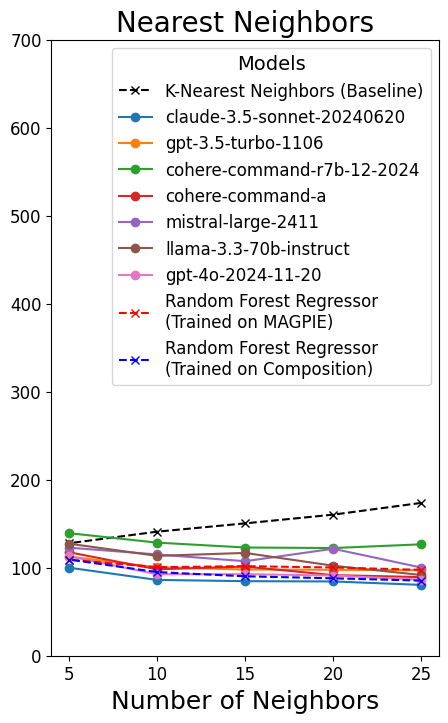

In [20]:
# plot the Nearest MAE vs num_points and label the models using dashed lines with point markers
plt.figure(figsize=(5,8))
plt.plot(df[df['model']=='baseline_mean_retrieval']['num_points'], df[df['model']=='baseline_mean_retrieval']['Nearest MAE'], 'x--', label='K-Nearest Neighbors (Baseline)',color = 'black')
plt.plot(df[df['model']=='claude_35_sonnet_retrieval']['num_points'], df[df['model']=='claude_35_sonnet_retrieval']['Nearest MAE'], 'o-', label='claude-3.5-sonnet-20240620')
plt.plot(df[df['model']=='gpt_35_turbo_retrieval']['num_points'], df[df['model']=='gpt_35_turbo_retrieval']['Nearest MAE'], 'o-', label='gpt-3.5-turbo-1106')
plt.plot(df[df['model']=='cohere_command_r7b_retrieval']['num_points'], df[df['model']=='cohere_command_r7b_retrieval']['Nearest MAE'], 'o-', label='cohere-command-r7b-12-2024')
plt.plot(df[df['model']=='cohere_command_a_retrieval']['num_points'], df[df['model']=='cohere_command_a_retrieval']['Nearest MAE'], 'o-', label='cohere-command-a')
plt.plot(df[df['model']=='mistral_large_retrieval']['num_points'], df[df['model']=='mistral_large_retrieval']['Nearest MAE'], 'o-', label='mistral-large-2411')
plt.plot(df[df['model']=='llama_33_70b_retrieval']['num_points'], df[df['model']=='llama_33_70b_retrieval']['Nearest MAE'], 'o-', label='llama-3.3-70b-instruct')
plt.plot(df[df['model']=='gpt_4o_retrieval']['num_points'], df[df['model']=='gpt_4o_retrieval']['Nearest MAE'], 'o-', label='gpt-4o-2024-11-20')
plt.plot(df[df['model']=='random_forest_retrieval']['num_points'], df[df['model']=='random_forest_retrieval']['Nearest MAE'], 'x--', label='Random Forest Regressor \n(Trained on MAGPIE)',color = 'red')
plt.plot(df[df['model']=='random_forest_retrieval_Comp']['num_points'], df[df['model']=='random_forest_retrieval_Comp']['Nearest MAE'], 'x--', label='Random Forest Regressor \n(Trained on Composition)',color = 'blue')
plt.xlabel('Number of Neighbors', fontsize=18)
#plt.ylabel('MAE', fontsize=12)
plt.title('Nearest Neighbors', fontsize=20)
plt.legend(title = 'Models', fontsize=12, title_fontsize='14')
# dont use decimals in xticks
plt.xticks(np.arange(5, 26, 5), fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0,700)
#plot a horizontal line at 79.9468
#plt.axhline(y=79.9468, color='r', linestyle='--')
plt.show()


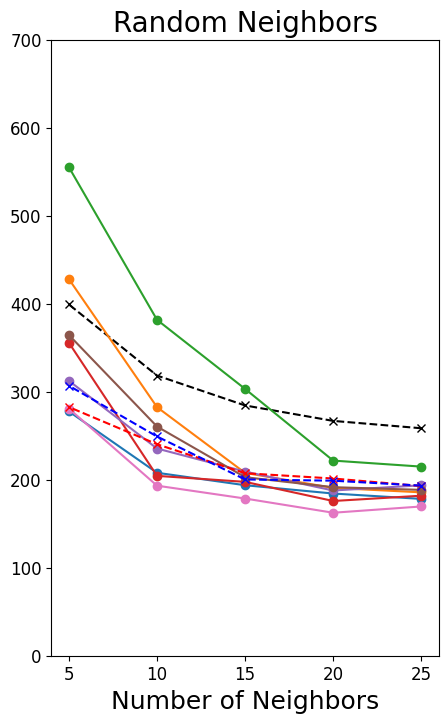

In [21]:
# do the same for Random MAE
plt.figure(figsize=(5,8))
plt.plot(df[df['model']=='baseline_mean_retrieval']['num_points'], df[df['model']=='baseline_mean_retrieval']['Random MAE'], 'x--', label='Baseline' ,color = 'black')
plt.plot(df[df['model']=='claude_35_sonnet_retrieval']['num_points'], df[df['model']=='claude_35_sonnet_retrieval']['Random MAE'], 'o-', label='claude-3.5-sonnet')
plt.plot(df[df['model']=='gpt_35_turbo_retrieval']['num_points'], df[df['model']=='gpt_35_turbo_retrieval']['Random MAE'], 'o-', label='gpt-3.5-turbo')
plt.plot(df[df['model']=='cohere_command_r7b_retrieval']['num_points'], df[df['model']=='cohere_command_r7b_retrieval']['Random MAE'], 'o-', label='cohere-command-r7b')
plt.plot(df[df['model']=='cohere_command_a_retrieval']['num_points'], df[df['model']=='cohere_command_a_retrieval']['Random MAE'], 'o-', label='cohere-command-a')
plt.plot(df[df['model']=='mistral_large_retrieval']['num_points'], df[df['model']=='mistral_large_retrieval']['Random MAE'], 'o-', label='mistral-large')
plt.plot(df[df['model']=='llama_33_70b_retrieval']['num_points'], df[df['model']=='llama_33_70b_retrieval']['Random MAE'], 'o-', label='llama-3.3-70b')
plt.plot(df[df['model']=='gpt_4o_retrieval']['num_points'], df[df['model']=='gpt_4o_retrieval']['Random MAE'], 'o-', label='gpt-4o')
plt.plot(df[df['model']=='random_forest_retrieval']['num_points'], df[df['model']=='random_forest_retrieval']['Random MAE'], 'x--', label='\n(Trained on MAGPIE)',color = 'red')
plt.plot(df[df['model']=='random_forest_retrieval_Comp']['num_points'], df[df['model']=='random_forest_retrieval_Comp']['Random MAE'], 'x--', label='Random Forest Regressor \n(Trained on Composition)',color = 'blue')
plt.xlabel('Number of Neighbors', fontsize=18)
#plt.ylabel('MAE', fontsize=12)
plt.title('Random Neighbors', fontsize=20)
#plt.legend()
# dont use decimals in xticks
plt.xticks(np.arange(5, 26, 5), fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0,700)
plt.show()


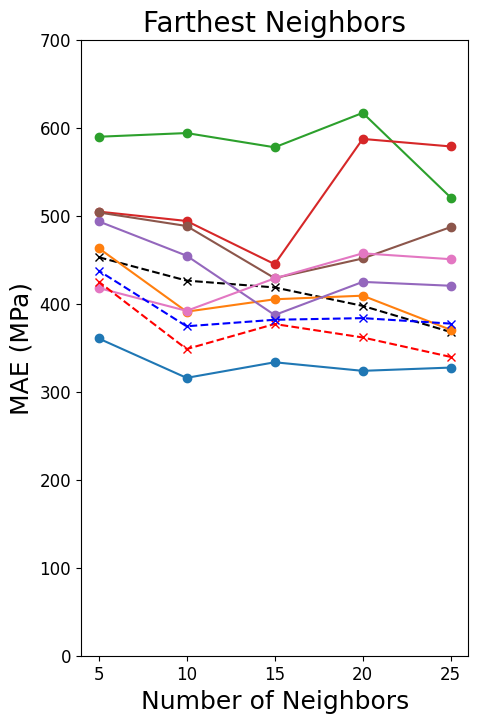

In [22]:
# do the same for Farthest MAE
plt.figure(figsize=(5,8))
plt.plot(df[df['model']=='baseline_mean_retrieval']['num_points'], df[df['model']=='baseline_mean_retrieval']['Farthest MAE'], 'x--', label='baseline_mean_retrieval',color = 'black')
plt.plot(df[df['model']=='claude_35_sonnet_retrieval']['num_points'], df[df['model']=='claude_35_sonnet_retrieval']['Farthest MAE'], 'o-', label='claude_35_sonnet_retrieval')
plt.plot(df[df['model']=='gpt_35_turbo_retrieval']['num_points'], df[df['model']=='gpt_35_turbo_retrieval']['Farthest MAE'], 'o-', label='gpt_35_turbo_retrieval')
plt.plot(df[df['model']=='cohere_command_r7b_retrieval']['num_points'], df[df['model']=='cohere_command_r7b_retrieval']['Farthest MAE'], 'o-', label='cohere_command_r7b_retrieval')
plt.plot(df[df['model']=='cohere_command_a_retrieval']['num_points'], df[df['model']=='cohere_command_a_retrieval']['Farthest MAE'], 'o-', label='cohere_command_a_retrieval')
plt.plot(df[df['model']=='mistral_large_retrieval']['num_points'], df[df['model']=='mistral_large_retrieval']['Farthest MAE'], 'o-', label='mistral_large_retrieval')
plt.plot(df[df['model']=='llama_33_70b_retrieval']['num_points'], df[df['model']=='llama_33_70b_retrieval']['Farthest MAE'], 'o-', label='llama_33_70b_retrieval')
plt.plot(df[df['model']=='gpt_4o_retrieval']['num_points'], df[df['model']=='gpt_4o_retrieval']['Farthest MAE'], 'o-', label='gpt_4o_retrieval')
plt.plot(df[df['model']=='random_forest_retrieval']['num_points'], df[df['model']=='random_forest_retrieval']['Farthest MAE'], 'x--', label='random_forest_retrieval \n(Trained on MAGPIE)',color = 'red')
plt.plot(df[df['model']=='random_forest_retrieval_Comp']['num_points'], df[df['model']=='random_forest_retrieval_Comp']['Farthest MAE'], 'x--', label='random_forest_retrieval_Comp \n(Trained on Composition)',color = 'blue')
plt.xlabel('Number of Neighbors', fontsize=18)
plt.ylabel('MAE (MPa)', fontsize=18)
plt.title('Farthest Neighbors', fontsize=20)
#plt.legend()
# dont use decimals in xticks
plt.xticks(np.arange(5, 26, 5), fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0,700)
plt.show()



# Parity plots for Mode Collapse Study

R^2:  0.84
MAE:  80.5


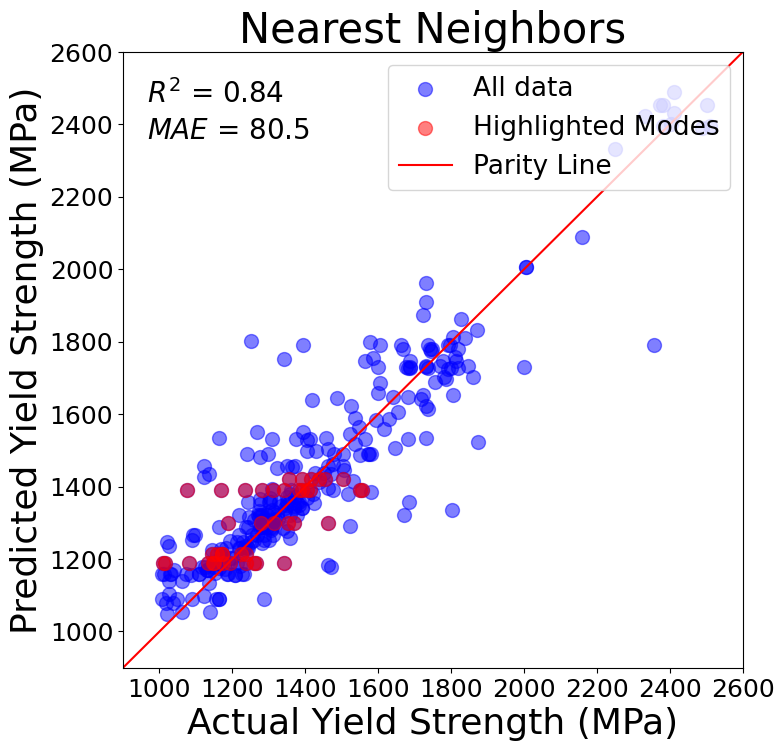

R^2:  0.01
MAE:  327.45


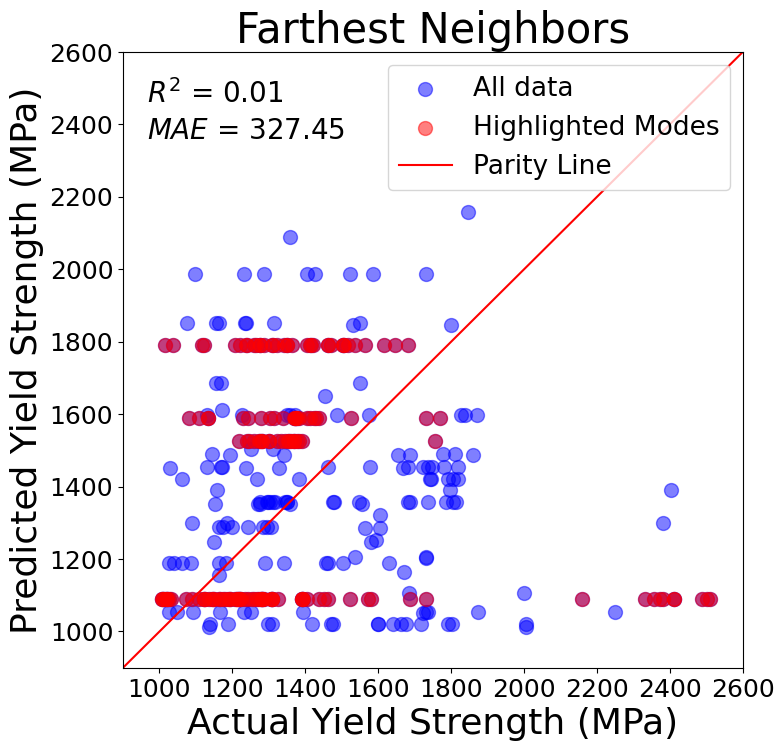

R^2:  0.41
MAE:  178.21


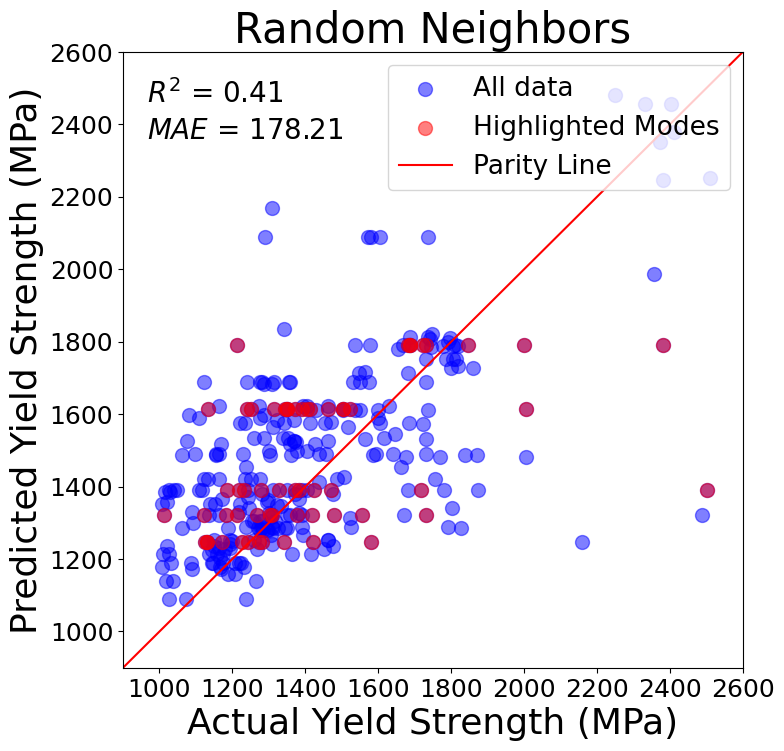

In [23]:
def plot_parity_size(df, model_name, plot=False):
    predicted_cols = [col for col in df.columns if 'predicted' in col and '_yield_strength' not in col]
    # do the same plot for every predicted yield strength
    for col in predicted_cols:
        # show r^2
        r2 = np.corrcoef(df['yield strength'], df[col+'_yield_strength'])[0,1]**2
        # calculate MAE
        MAE = np.mean(np.abs(df['yield strength'] - df[col+'_yield_strength']))
        if plot:
            plt.figure(figsize=(8,8))
            # Scatter plot for all points
            plt.scatter(df['yield strength'], df[col+'_yield_strength'], color='blue', label='All data', alpha=0.5, s=100)
            # Plot the top 5 highest value counts of the predicted yield strength as red points
            top_5 = df[col+'_yield_strength'].value_counts().head(5).index
            first = True  # Flag to check if the first top value is being plotted
            for i in top_5:
                if first:
                    plt.scatter(df['yield strength'][df[col+'_yield_strength'] == i], df[col+'_yield_strength'][df[col+'_yield_strength'] == i], color='red', label='Highlighted Modes', alpha=0.5, s=100)
                    first = False
                else:
                    plt.scatter(df['yield strength'][df[col+'_yield_strength'] == i], df[col+'_yield_strength'][df[col+'_yield_strength'] == i], color='red', alpha=0.5, s=100)
            # draw a diagonal line
            #x = np.linspace(min(df['yield strength']), max(df['yield strength']), 100)
            x = np.linspace(900,2600, 100)
            y = x
            plt.plot(x, y, '-r', label='Parity Line')
            print('R^2: ', round(r2, 2))
            print('MAE: ', round(MAE, 2))
            plt.xlabel('Actual Yield Strength (MPa)', fontsize=26)
            plt.ylabel('Predicted Yield Strength (MPa)', fontsize=26)
            plt.title(col.split('_')[0][10:].title() + ' Neighbors', fontsize=30)
            plt.text(min(df['yield strength'])-40, max(df['yield strength'])-50, '$R^2$ = ' + str(round(r2, 2)), fontsize=20)
            plt.text(min(df['yield strength'])-40, max(df['yield strength']) - 150, '$MAE$ = ' + str(round(MAE, 2)), fontsize=20)
            plt.xticks(fontsize=18)
            plt.yticks(fontsize=18)
            plt.legend(loc = 'upper right', fontsize=19)
            plt.xlim(900, 2600)
            plt.ylim(900, 2600)
            plt.show()

# Call the function with your DataFrame and model_name
plot_parity_size(claude_35_sonnet_retrieval_25points, 'claude-3.5-sonnet', plot=True)


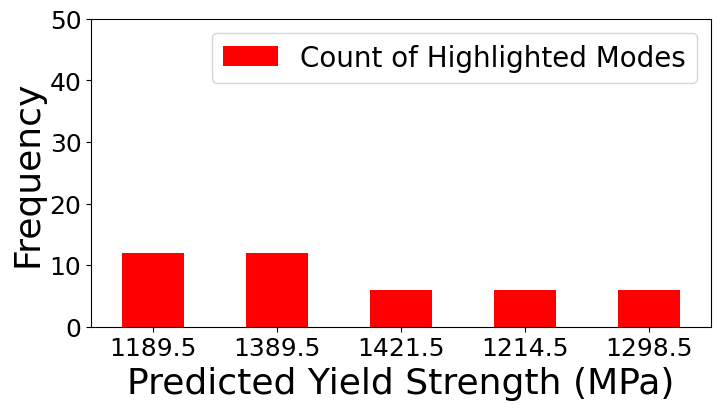

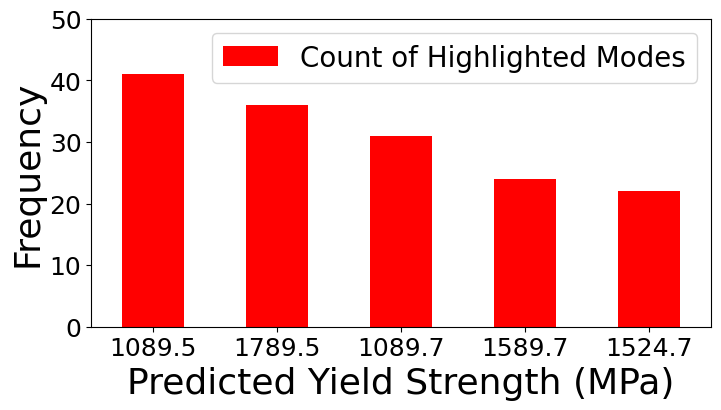

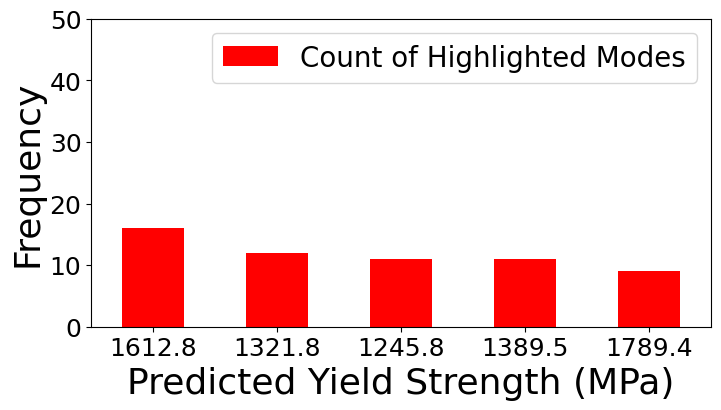

In [24]:
# claude
# plot the top 10 highest value counts of the predicted yield strength on the same plot side by side
def plot_value_counts(df, model_name):
    predicted_cols = [col for col in df.columns if 'predicted' in col and '_yield_strength' in col]
    for col in predicted_cols:
        plt.figure(figsize=(8,4))
        df[col].value_counts().head(5).plot(kind='bar', color='red')
        plt.xlabel('Predicted Yield Strength (MPa)', fontsize=26)
        plt.ylabel('Frequency', fontsize=26)
        #plt.title('Mode Collapse Points Count - ' + col.split('_')[0][10:].title() + ' Neighbors', fontsize=24)
        plt.xticks(fontsize=18)
        plt.yticks(fontsize=18)
        plt.ylim(0, 50)
        # change x-axis rotation
        plt.xticks(rotation=0)
        plt.legend(['Count of Highlighted Modes'], fontsize=20)
        plt.show()


plot_value_counts(claude_35_sonnet_retrieval_25points, 'claude-3.5-sonnet')

# PCA plot for SI

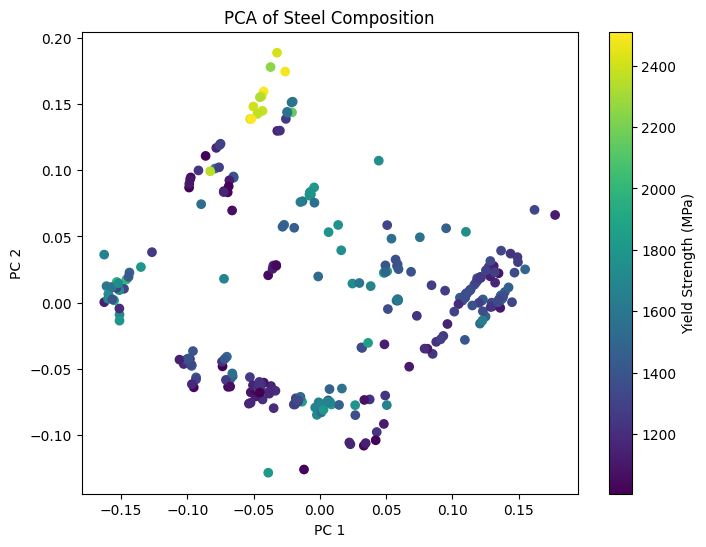

In [25]:
with open('steels_yield.json') as json_data:
    data = json.load(json_data)
    df = pd.DataFrame(data['data'],columns=data['columns']).sample(frac=1, random_state=42).reset_index(drop=True)

# Custom function to parse the composition strings
def custom_parse_composition(comp_str):
    # Regular expression to match elements and their amounts
    pattern = re.compile(r'([A-Z][a-z]*)([0-9\.]+)')
    return dict(pattern.findall(comp_str))

# Apply the custom parsing function
element_data = df['composition'].apply(custom_parse_composition)

# Convert the list of dictionaries into a DataFrame
element_df = pd.DataFrame(list(element_data))

# Replace missing values with 0
element_df = element_df.fillna(0)

# Convert string numbers to float
element_df = element_df.apply(pd.to_numeric)

# Combine the element DataFrame with the original DataFrame
df = pd.concat([df, element_df], axis=1)


n_components = min(element_df.shape)
pca = PCA(n_components)
pca.fit(element_df)
loading_vectors = pca.components_
explained_variance = pca.explained_variance_
pos = pca.transform(element_df)

# color the points by the yield strength
plt.figure(1, figsize=(8,6))
plt.scatter(pos[:,0],pos[:,1],c=df['yield strength'])
plt.xlabel('PC 1')
plt.ylabel('PC 2')
# name the plot and the colorbar
plt.title('PCA of Steel Composition')
cbar = plt.colorbar()
cbar.set_label('Yield Strength (MPa)')
plt.show()
